
## Example 6.2.1



$$
u'=\sin[(u+t)^2], \quad t \in [0,4], \quad u(0)=-1
$$

In [9]:
using OrdinaryDiffEq
f(u, p, t) = sin((t + u)^2)
tspan = (0.0, 4.0)
u0 = -1.0
ivp = ODEProblem(f, u0, tspan)

ODEProblem with uType Float64 and tType Float64. In-place: false
Non-trivial mass matrix: false
timespan: (0.0, 4.0)
u0: -1.0

In [10]:
using FNCFunctions
t, u = FNC.euler(ivp, 20)

([0.0, 0.2, 0.4, 0.6000000000000001, 0.8, 1.0, 1.2000000000000002, 1.4000000000000001, 1.6, 1.8  …  2.2, 2.4000000000000004, 2.6, 2.8000000000000003, 3.0, 3.2, 3.4000000000000004, 3.6, 3.8000000000000003, 4.0], [-1.0, -0.8317058030384207, -0.753996761875809, -0.7289995644729605, -0.7256715405500015, -0.7245666021940985, -0.7094084405462577, -0.6617358091071972, -0.5580463735404682, -0.381123410298443  …  -0.21975725067359766, -0.36038024284874315, -0.5306400392716878, -0.7124216540429389, -0.8999922381452977, -1.0909197340336547, -1.2839816753594941, -1.4784912740075555, -1.674030931828329, -1.8703312046863438])

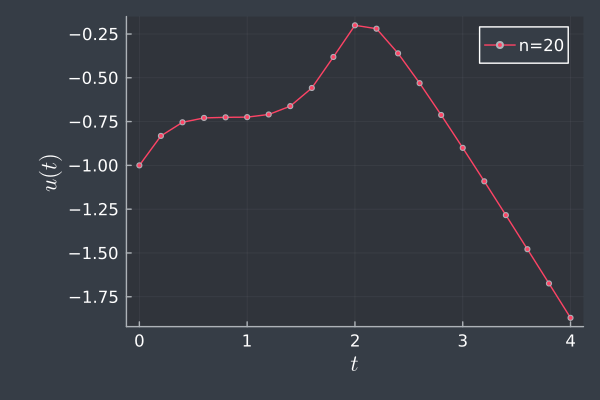

In [11]:
using Plots, LaTeXStrings
theme(:dark);  default(thickness_scaling=1.4)
plot(t, u; m=2, label="n=20", xlabel=L"t",  ylabel=L"u(t)")

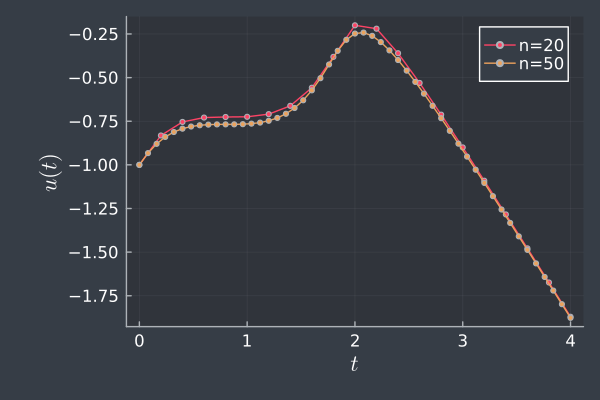

In [12]:
t, u = FNC.euler(ivp, 50)
plot!(t, u, m=2, label="n=50")

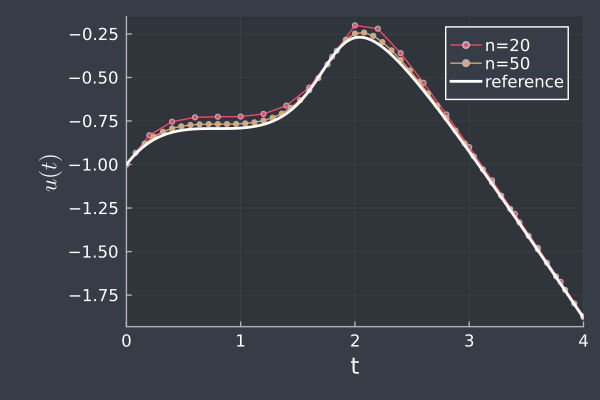

In [13]:
u_exact = solve(ivp, reltol=1e-14, abstol=1e-14)
plot!(u_exact, l=(2, :white), label="reference")

In [14]:
using PrettyTables
n = [round(Int, 5 * 10^k) for k in 0:0.5:3]
err = []
for n in n
    t, u = FNC.euler(ivp, n)
    push!(err, maximum(abs, u_exact.(t) - u))
end
pretty_table((n=n, err=err); column_labels=["n", "inf-norm error"], backend=:html)

n,inf-norm error
5,2.7342
16,0.107594
50,0.0299962
158,0.00885025
500,0.00273659
1581,0.000859654
5000,0.000271243


$$h=\frac{b-a}{n} \implies O(h)=O(n^{-1})$$

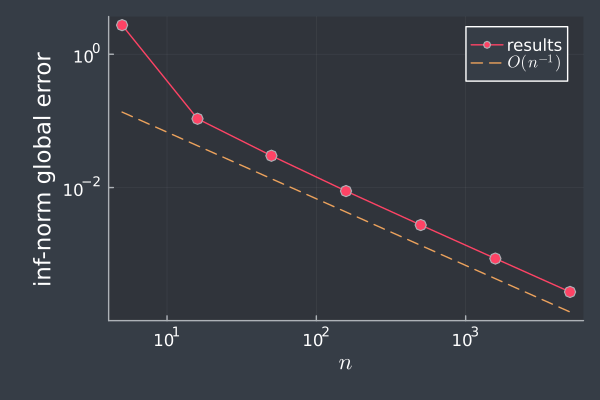

In [15]:
plot(n, err; m=:o, label="results",
    xaxis=(:log10, L"n"),  yaxis=(:log10, "inf-norm global error"))
# Add line for perfect 1st order.
plot!(n, 0.5 * err[end] * (n / n[end]) .^ (-1), l=:dash, label=L"O(n^{-1})")